In [8]:
#IMPORT THE NECESSARY LIBRARIES FOR READING AND LOADING FINANCE DATA
import pandas as pd

df = pd.read_csv("C:/Data/yfinance_data/Data/AAPL.csv")
# Load datasets
Amazone = pd.read_csv("C:/Data/yfinance_data/Data/AMZN.csv")
Google = pd.read_csv("C:/Data/yfinance_data/Data/GOOG.csv")
Meta = pd.read_csv("C:/Data/yfinance_data/Data/META.csv")
Nvda=pd.read_csv("C:/Data/yfinance_data/Data/NVDA.csv")

print(df.head())

         Date     Close      High       Low      Open      Volume
0  2009-01-02  2.721686  2.730385  2.554037  2.575630   746015200
1  2009-01-05  2.836553  2.884539  2.780469  2.794266  1181608400
2  2009-01-06  2.789767  2.914229  2.770872  2.877641  1289310400
3  2009-01-07  2.729484  2.774170  2.706990  2.753477   753048800
4  2009-01-08  2.780169  2.793666  2.700393  2.712090   673500800


In [16]:
print(df.info())
print(df.columns)

<class 'pandas.DataFrame'>
RangeIndex: 3774 entries, 0 to 3773
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    3774 non-null   str    
 1   Close   3774 non-null   float64
 2   High    3774 non-null   float64
 3   Low     3774 non-null   float64
 4   Open    3774 non-null   float64
 5   Volume  3774 non-null   int64  
dtypes: float64(4), int64(1), str(1)
memory usage: 177.0 KB
None
Index(['Date', 'Close', 'High', 'Low', 'Open', 'Volume'], dtype='str')


In [18]:
df['Date'] = pd.to_datetime(df['Date'])

In [19]:
numeric_cols = ['Open', 'High', 'Low', 'Close', 'Volume']

df[numeric_cols] = df[numeric_cols].apply(pd.to_numeric, errors='coerce')

In [20]:
print(df.isnull().sum())

Date      0
Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64


In [21]:
df = df.ffill()

In [22]:
print(df.info())
print(df.head())

<class 'pandas.DataFrame'>
RangeIndex: 3774 entries, 0 to 3773
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    3774 non-null   datetime64[us]
 1   Close   3774 non-null   float64       
 2   High    3774 non-null   float64       
 3   Low     3774 non-null   float64       
 4   Open    3774 non-null   float64       
 5   Volume  3774 non-null   int64         
dtypes: datetime64[us](1), float64(4), int64(1)
memory usage: 177.0 KB
None
        Date     Close      High       Low      Open      Volume
0 2009-01-02  2.721686  2.730385  2.554037  2.575630   746015200
1 2009-01-05  2.836553  2.884539  2.780469  2.794266  1181608400
2 2009-01-06  2.789767  2.914229  2.770872  2.877641  1289310400
3 2009-01-07  2.729484  2.774170  2.706990  2.753477   753048800
4 2009-01-08  2.780169  2.793666  2.700393  2.712090   673500800


In [27]:
print(df.columns)

Index(['Close', 'High', 'Low', 'Open', 'Volume'], dtype='str')


In [23]:
#Set Date as inde
df.set_index('Date', inplace=True)

In [28]:
#the following line of code converts date in to column
df['Close'] = pd.to_datetime(df['Close'])

In [33]:
import talib
import matplotlib.pyplot as plt

In [29]:
#ensuring the close values are numeric values
df['Close'] = pd.to_numeric(df['Close'], errors='coerce')

In [30]:
#Simple Moving Average (SMA)
 #SMA smooths price fluctuations to show trend direction.
df['SMA_20'] = talib.SMA(df['Close'], timeperiod=20)
df['SMA_50'] = talib.SMA(df['Close'], timeperiod=50)

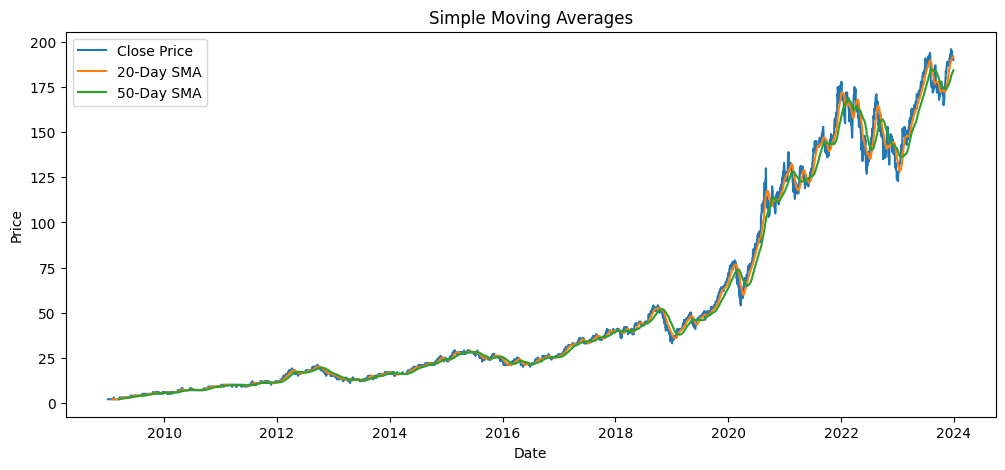

In [34]:
#the following line of code shows the smooth price fluctuation graphically
plt.figure(figsize=(12,5))

plt.plot(df.index, df['Close'], label='Close Price')
plt.plot(df.index, df['SMA_20'], label='20-Day SMA')
plt.plot(df.index, df['SMA_50'], label='50-Day SMA')

plt.title("Simple Moving Averages")
plt.xlabel("Date")
plt.ylabel("Price")

plt.legend()
plt.show()

In [ ]:
#Short SMA above long SMA → bullish trend
#Short SMA below long SMA → bearish trend

In [35]:
#EMA calculates the weights average of the recent price
df['EMA_20'] = talib.EMA(df['Close'], timeperiod=20)
df['EMA_50'] = talib.EMA(df['Close'], timeperiod=50)

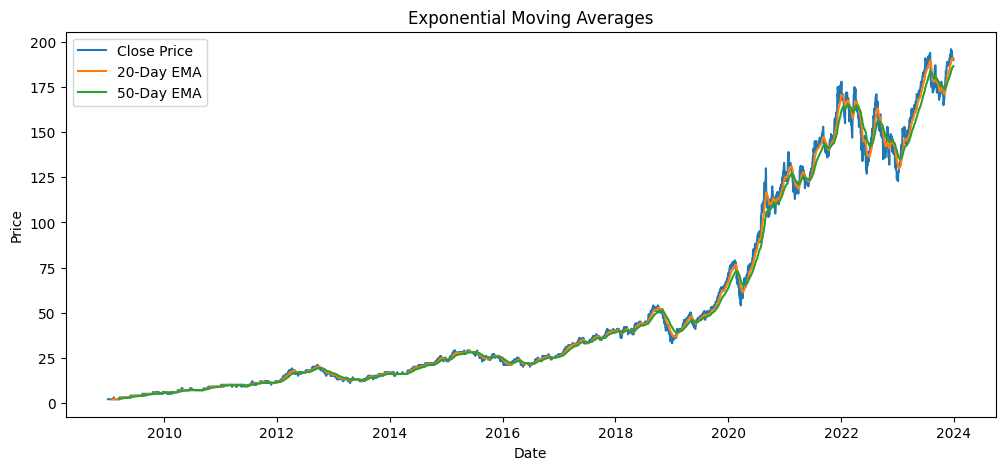

In [36]:
#Visualize EMA the reccent average prices of items between the five campanys'
plt.figure(figsize=(12,5))

plt.plot(df.index, df['Close'], label='Close Price')
plt.plot(df.index, df['EMA_20'], label='20-Day EMA')
plt.plot(df.index, df['EMA_50'], label='50-Day EMA')

plt.title("Exponential Moving Averages")
plt.xlabel("Date")
plt.ylabel("Price")

plt.legend()
plt.show()

In [37]:
#EMA reacts faster to:

#price jumps
#reversals
#momentum changes

#This makes it useful for short-term trading signals.

In [38]:
#Relative Strength Index (RSI)

#RSI measures momentum and detects:

#overbought conditions
#oversold conditions
df['RSI'] = talib.RSI(df['Close'], timeperiod=14)

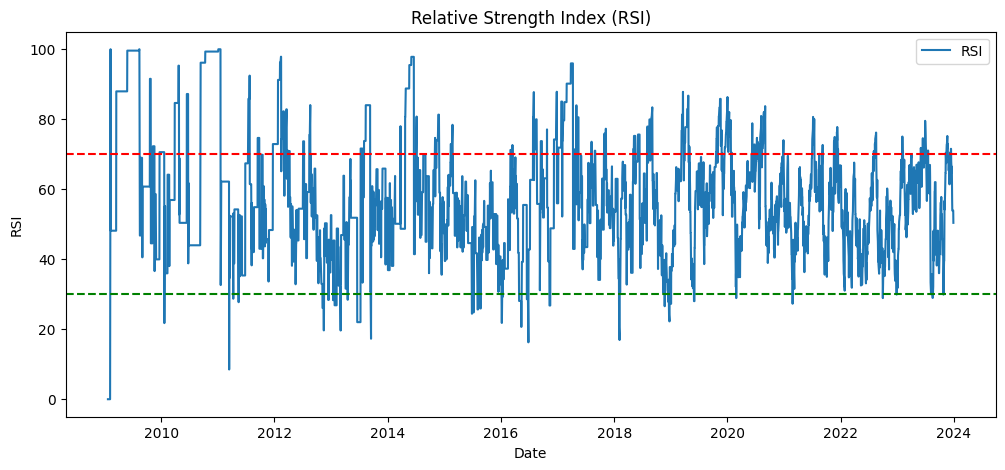

In [39]:
plt.figure(figsize=(12,5))

plt.plot(df.index, df['RSI'], label='RSI')

plt.axhline(70, color='red', linestyle='--')
plt.axhline(30, color='green', linestyle='--')

plt.title("Relative Strength Index (RSI)")
plt.xlabel("Date")
plt.ylabel("RSI")

plt.legend()
plt.show()

In [40]:
#Interpretation of RSI
#RSI > 70 → overbought (possible price drop)
#RSI < 30 → oversold (possible price rise)

In [41]:
#MACD (Momentum Indicator)

#MACD detects:

#momentum shifts
#trend reversals


In [42]:
#Calculate MACD
df['MACD'], df['MACD_signal'], df['MACD_hist'] = talib.MACD(
    df['Close'],
    fastperiod=12,
    slowperiod=26,
    signalperiod=9
)

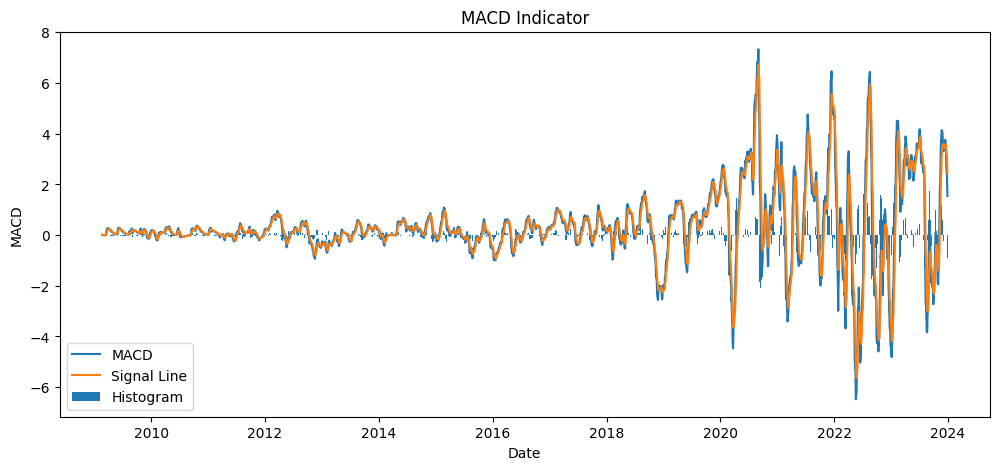

In [43]:
#Visualize MACD
plt.figure(figsize=(12,5))

plt.plot(df.index, df['MACD'], label='MACD')
plt.plot(df.index, df['MACD_signal'], label='Signal Line')

plt.bar(df.index, df['MACD_hist'], label='Histogram')

plt.title("MACD Indicator")
plt.xlabel("Date")
plt.ylabel("MACD")

plt.legend()
plt.show()

In [44]:
#Interpretation of MACD
#Bullish signal

#When:

#3MACD crosses ABOVE signal line

#Possible upward momentum.

#Bearish signal

#When:

#MACD crosses BELOW signal line

#Possible downward momentum.

In [45]:
print(df[['Close', 'SMA_20', 'EMA_20', 'RSI', 'MACD']].tail())

            Close  SMA_20      EMA_20        RSI      MACD
Date                                                      
2023-12-22    191  191.40  191.036070  53.901878  2.644353
2023-12-26    191  191.55  191.032634  53.901878  2.333142
2023-12-27    191  191.70  191.029526  53.901878  2.062727
2023-12-28    191  191.90  191.026714  53.901878  1.827357
2023-12-29    190  192.00  190.928932  50.396194  1.542353


In [49]:
#Import libraries vaderSentiment
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from scipy.stats import pearsonr

In [57]:
from pathlib import Path
print(Path.cwd())

C:\Users\Soret\news-sentiment-analysis


In [59]:
from pathlib import Path
import pandas as pd

BASE_DIR = Path.cwd()

DATA_PATH = BASE_DIR / "data" / "raw" / "news.csv"

news_df = pd.read_csv(DATA_PATH)

print(news_df.head())

                                    headline sentiment
0       Stocks surge after positive earnings  positive
1  Company reports terrible financial losses  negative
2             Market remains unchanged today   neutral


In [10]:
import pandas as pd

# Load stock datasets
AAPL = pd.read_csv("C:/Data/yfinance_data/Data/AAPL.csv")
AMZN = pd.read_csv("C:/Data/yfinance_data/Data/AMZN.csv")
GOOG = pd.read_csv("C:/Data/yfinance_data/Data/GOOG.csv")
META = pd.read_csv("C:/Data/yfinance_data/Data/META.csv")
NVDA = pd.read_csv("C:/Data/yfinance_data/Data/NVDA.csv")

In [12]:
AAPL["stock"] = "AAPL"
AMZN["stock"] = "AMZN"
GOOG["stock"] = "GOOG"
META["stock"] = "META"
NVDA["stock"] = "NVDA"

In [16]:
stocks = pd.concat(
    [AAPL, AMZN, GOOG, META, NVDA],
    ignore_index=True
)

In [18]:
stocks.head()

,Date,Close,High,Low,Open,Volume,stock
0,2009-01-02,2.721686,2.730385,2.554037,2.575630,746015200,AAPL
1,2009-01-05,2.836553,2.884539,2.780469,2.794266,1181608400,AAPL
2,2009-01-06,2.789767,2.914229,2.770872,2.877641,1289310400,AAPL
3,2009-01-07,2.729484,2.774170,2.706990,2.753477,753048800,AAPL
4,2009-01-08,2.780169,2.793666,2.700393,2.712090,673500800,AAPL


In [20]:
stocks["Date"] = pd.to_datetime(stocks["Date"])

In [21]:
stocks = stocks.sort_values(["stock", "Date"])

In [23]:
stocks["daily_return"] = (
    stocks.groupby("stock")["Close"]
    .pct_change() * 100
)

In [24]:
stocks["daily_return"]

0             NaN
1        4.220416
2       -1.649399
3       -2.160860
4        1.856959
           ...   
18014   -0.326597
18015    0.919511
18016    0.280040
18017    0.212490
18018    0.000000
Name: daily_return, Length: 18019, dtype: float64

In [27]:
print(news["date"].head())

0    2020-06-05 10:30:54-04:00
1    2020-06-03 10:45:20-04:00
2    2020-05-26 04:30:07-04:00
3    2020-05-22 12:45:06-04:00
4    2020-05-22 11:38:59-04:00
Name: date, dtype: str


In [28]:
news["date"] = pd.to_datetime(
    news["date"],
    format="%Y-%m-%d %H:%M:%S",
    errors="coerce"
)

In [29]:
print(news["date"].dtype)

datetime64[us]


In [30]:
#Convert the news Dates 
news["date"] = pd.to_datetime(news["date"])
stocks["Date"] = pd.to_datetime(stocks["Date"])


In [32]:
trading_days = set(pd.to_datetime(stocks["Date"]))

In [33]:
#Align News to Trading Days
#Handle weekends and holidays

#If news is published on a non-trading day:
#➡ shift to next trading day
def align_to_trading_day(news_date):

    while news_date not in trading_days:
        news_date += pd.Timedelta(days=1)

    return news_date

In [ ]:
news["trading_day"] = news["date"].apply(align_to_trading_day)

In [ ]:
#Sentiment Analysis
#VADER was selected because it is optimized for short text and performs well on financial headlines and social-media-style content. It provides normalized polarity scores suitable for quantitative analysis.
analyzer = SentimentIntensityAnalyzer()

def get_sentiment(text):
    return analyzer.polarity_scores(text)["compound"]

news["sentiment_score"] = news["headline"].apply(get_sentiment)

In [ ]:
#Aggregate Daily Sentiment

#If multiple articles exist for the same day:

#➡ compute average sentiment
daily_sentiment = (
    news
    .groupby(["trading_day", "stock"])["sentiment_score"]
    .mean()
    .reset_index()
)

In [ ]:
#Calculate Daily Stock Returns
stocks = stocks.sort_values(["stock", "Date"])

stocks["daily_return"] = (
    stocks.groupby("stock")["Close"]
    .pct_change() * 100
)

In [ ]:
#Merge Sentiment + Returns
